# EDA Bivariate Analysis: Amazon UK Product Insights — Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

In [2]:

df = pd.read_csv('database/amz_uk_price_prediction_dataset.csv')
df.shape, df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 495.8 MB


((2443651, 9), None)

## Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

### Crosstab Analysis

Create a crosstab between the product `category` and the `isBestSeller` status. Are there categories where being a best-seller is more prevalent?

In [19]:
best_seller_ct = pd.crosstab(df['category'], df['isBestSeller'])
best_seller_ct.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [20]:
best_seller_prop = df.groupby('category')['isBestSeller'].mean().sort_values(ascending=False)
best_seller_prop.head(10)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Name: isBestSeller, dtype: float64

Yes, though the proportions are small across the board. From best_seller_prop, the categories with the highest best-seller rate are Grocery (5.8%), Smart Home Security & Lighting (5.77%), Health & Personal Care (5.77%), Mobile Phone Accessories (4.25%), and Power & Hand Tools (3.53%). Notably, Sports & Outdoors — despite having 91%+ of all listings — doesn't top this list, since this metric is a rate (best-sellers ÷ total listings in that category), not raw count. That's a good example of why the proportion-based view answers a different question than the crosstab counts alone.

### Statistical Tests

Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category. Compute Cramér's V to understand the strength of association between best-seller status and category.

In [5]:
chi2, p_value, dof, expected = chi2_contingency(best_seller_ct)
chi2, p_value

(np.float64(36540.20270061387), np.float64(0.0))

In [6]:
cramers_v = association(best_seller_ct, method='cramer')
cramers_v

0.1222829439760564

The chi-square test gives χ² ≈ 36,540 with p ≈ 0.0, so you reject independence — category and best-seller status are statistically related. But Cramér's V = 0.122, which is a weak association on a 0–1 scale. This is the classic large-sample trap: with 2.4M rows, even a small, practically minor relationship produces a vanishingly small p-value. The honest conclusion is: category does influence best-seller likelihood, but only weakly — category alone is a poor predictor of best-seller status.

### Visualization

Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

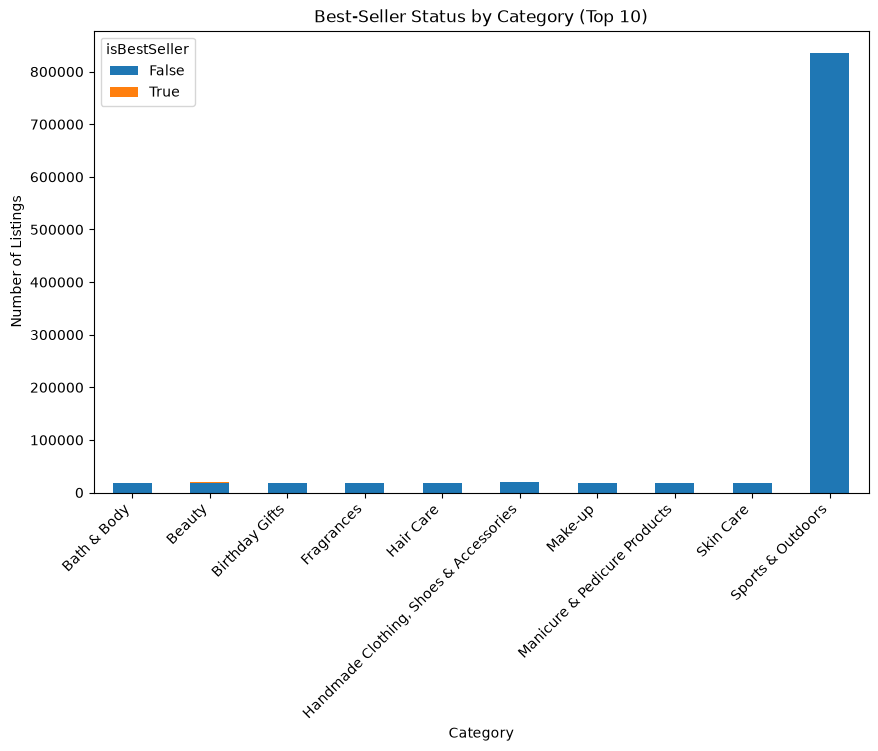

In [7]:
top_categories = df['category'].value_counts().head(10).index
subset_ct = pd.crosstab(df[df['category'].isin(top_categories)]['category'],
                         df[df['category'].isin(top_categories)]['isBestSeller'])

subset_ct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Category')
plt.ylabel('Number of Listings')
plt.title('Best-Seller Status by Category (Top 10)')
plt.xticks(rotation=45, ha='right')
plt.show()

Visually, the "True" (best-seller) segment is barely visible in any bar — consistent with the Cramér's V finding, best-sellers are a thin sliver in every category, including Sports & Outdoors despite its massive listing count. The chart's main visual story is actually the same category-count imbalance from the univariate lab (one huge bar, nine tiny ones), which somewhat obscures the best-seller proportion differences — worth noting this chart is better for showing raw scale than for comparing best-seller rates across categories, which the earlier best_seller_prop table already does better.

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

### Preliminary Step: Remove Outliers in Product Prices

Using the IQR (Interquartile Range) method: products priced below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers and removed. All subsequent steps in this part use the outlier-free dataframe.

In [8]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
df.shape, df_no_outliers.shape

((2443651, 9), (2115963, 9))

### Violin Plots

Use a violin plot to visualize the distribution of `price` across different product categories (top 20 by count, for readability). Which product category tends to have the highest median price? *(Answer without filtering to top categories.)*

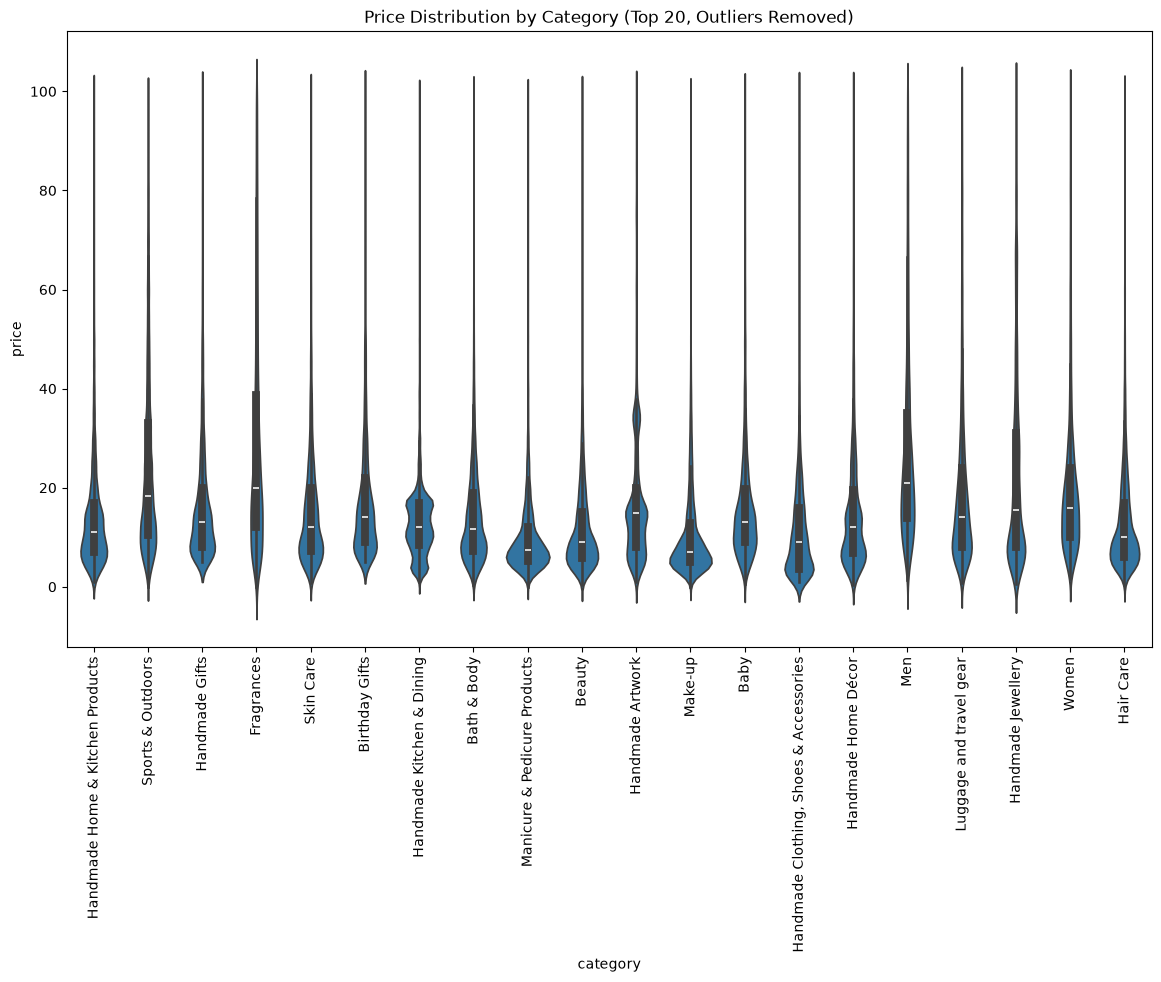

In [9]:
top_20 = df_no_outliers['category'].value_counts().head(20).index
subset_violin = df_no_outliers[df_no_outliers['category'].isin(top_20)]

plt.figure(figsize=(14, 8))
sns.violinplot(data=subset_violin, x='category', y='price')
plt.xticks(rotation=90)
plt.title('Price Distribution by Category (Top 20, Outliers Removed)')
plt.show()

In [10]:
median_price_by_cat = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
median_price_by_cat.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

Desktop PCs, at £74.00 median. Followed closely by Boxing Shoes (£69.79), Tablets (£69.00), Graphics Cards (£68.54), and Motherboards (£67.92). Notice this is a completely different list from anything in the top-20-by-count violin plot, confirming the earlier point that popular categories and expensive categories are not the same thing.

### Bar Charts

Create a bar chart comparing the average price of products for the top 10 product categories (by count). Which product category commands the highest average price? *(Answer without filtering to top categories.)*

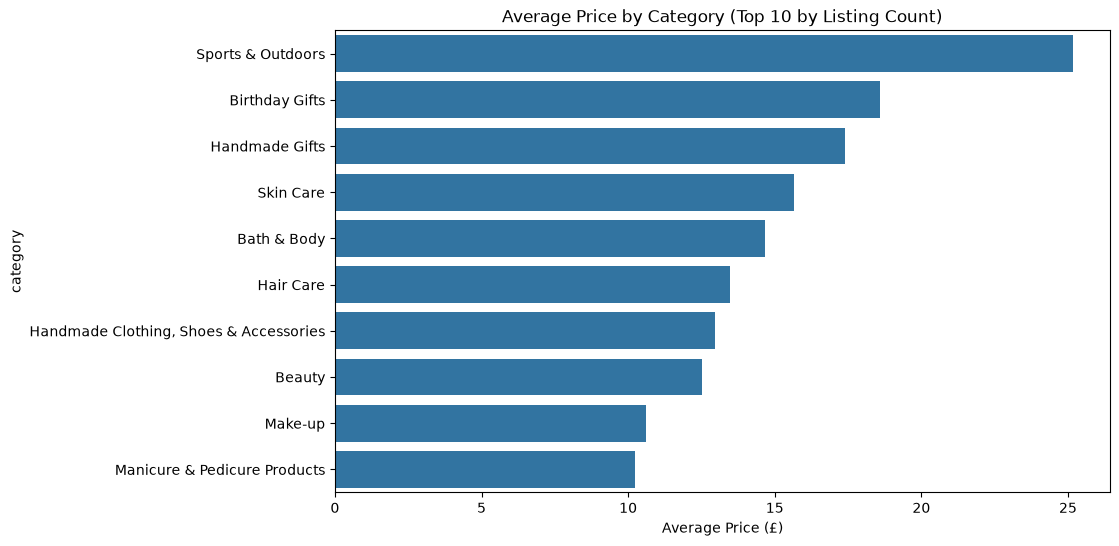

In [11]:
top_10 = df_no_outliers['category'].value_counts().head(10).index
avg_price_top10 = df_no_outliers[df_no_outliers['category'].isin(top_10)].groupby('category')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_top10.values, y=avg_price_top10.index)
plt.xlabel('Average Price (£)')
plt.title('Average Price by Category (Top 10 by Listing Count)')
plt.show()

In [12]:
avg_price_by_cat = df_no_outliers.groupby('category')['price'].mean().sort_values(ascending=False)
avg_price_by_cat.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

Motherboards, at £68.77 average, narrowly ahead of Boxing Shoes (£67.42), Desktop PCs (£66.92), Tablets (£66.55), and Graphics Cards (£65.10). Worth flagging: median-price winner (Desktop PCs) and mean-price winner (Motherboards) aren't the same category, and the same five categories appear in both lists just reordered. This cluster of computer-component categories is consistently expensive by either measure, a solid, well-supported finding for your report.

### Box Plots

Visualize the distribution of product ratings (`stars`) by `category` using side-by-side box plots (top 10 categories by count, for readability). Which category tends to receive the highest median rating from customers? *(Answer without filtering to top categories.)*

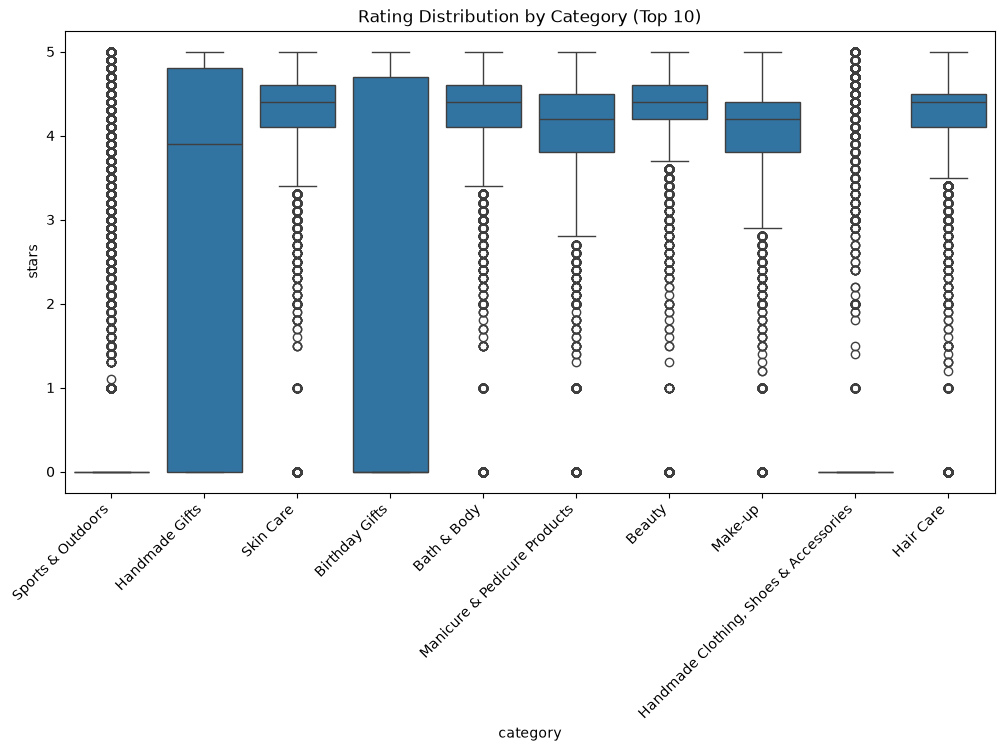

In [13]:
top_10_ratings = df_no_outliers['category'].value_counts().head(10).index
subset_box = df_no_outliers[df_no_outliers['category'].isin(top_10_ratings)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset_box, x='category', y='stars')
plt.xticks(rotation=45, ha='right')
plt.title('Rating Distribution by Category (Top 10)')
plt.show()

In [14]:
median_rating_by_cat = df_no_outliers.groupby('category')['stars'].median().sort_values(ascending=False)
median_rating_by_cat.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

Computer Memory, with a median of 4.7, followed by a large tie at 4.6 (Building & Construction Toys, Office Paper Products, Luxury Food & Drink, Kids' Play Figures, Hobbies, Beer/Wine & Spirits, Laptop Accessories), then 4.5 for Cables & Accessories and CPUs. One caution worth stating in your report, consistent with what we found in the univariate lab: given the zero-inflation in stars, a category needs a reasonable number of actually-rated products for this median to be meaningful, worth pairing this with a .count() check per category before presenting it as a definitive ranking, the same caveat as before.

## Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

### Correlation Coefficients

Calculate the correlation coefficient between `price` and `stars`. Is there a significant correlation between product price and its rating?

In [15]:
price_stars_corr = df_no_outliers['price'].corr(df_no_outliers['stars'])
price_stars_corr

np.float64(-0.0776729987818131)

The Pearson correlation is −0.0777 — essentially no linear relationship. Even though this may register as "statistically significant" given the sample size, a coefficient this close to zero means price tells you almost nothing about how a product is rated, and vice versa. This is a clear, reportable finding: price and customer satisfaction are effectively uncorrelated in this dataset.

### Visualizations

- Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
- Use a correlation heatmap to visualize correlations between all numerical variables.
- Examine whether product prices follow a normal distribution using a QQ plot.

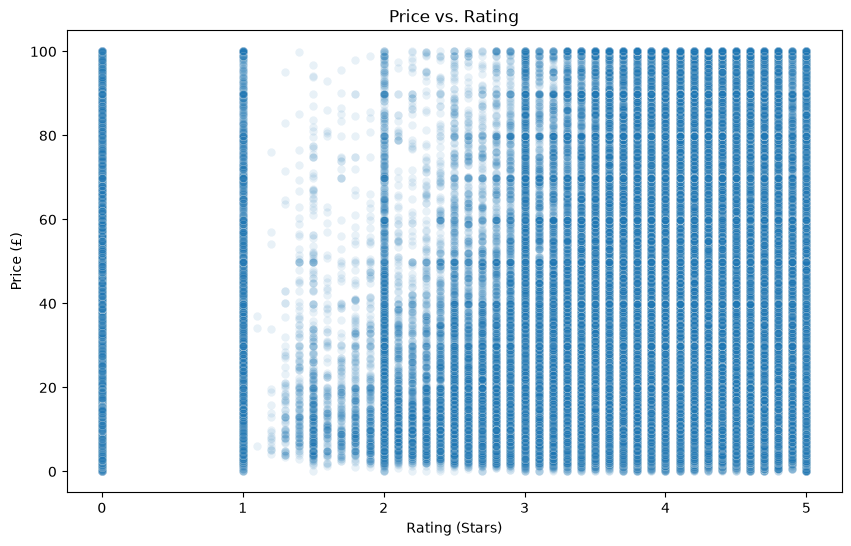

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_no_outliers, x='stars', y='price', alpha=0.1)
plt.xlabel('Rating (Stars)')
plt.ylabel('Price (£)')
plt.title('Price vs. Rating')
plt.show()

The most obvious pattern is vertical banding — points cluster into distinct columns at whole-number rating values (0, 1, 2, 3, 4, 5) rather than spreading continuously, because stars is a coarse, effectively discretized variable. The densest band by far sits at stars = 0, spanning the entire price range from £0 to £100 — reinforcing the zero-inflation finding from your univariate lab (a huge, price-indifferent mass of unrated products). Among genuinely rated products (stars 1–5), there's no visible upward or downward slope — prices scatter roughly evenly regardless of rating, visually confirming the near-zero correlation from 1b.

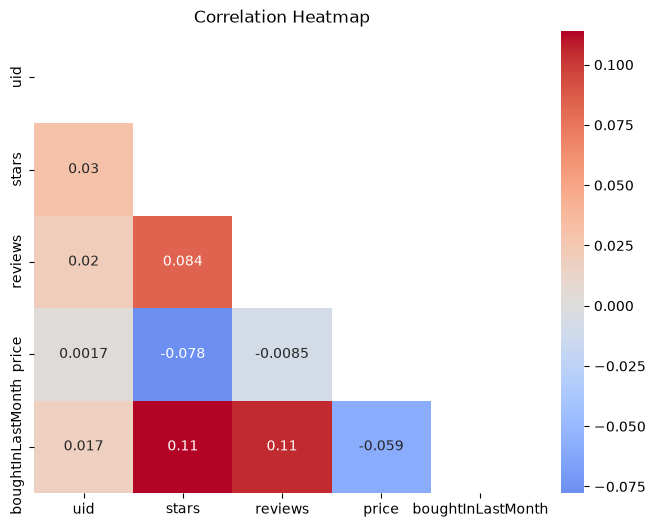

In [17]:
numeric_cols = df_no_outliers.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

The interesting relationships here aren't with price at all: stars vs. boughtInLastMonth (0.11) and reviews vs. boughtInLastMonth (0.11) are the strongest pairs in the matrix — still weak in absolute terms, but notably stronger than anything involving price, which sits near zero against every other variable (−0.0085 with stars, −0.078 with reviews, −0.059 with boughtInLastMonth). The takeaway worth stating explicitly: in this dataset, price is essentially decoupled from popularity, reviews, and ratings — recent purchase volume relates more to reviews and ratings than price does to anything.

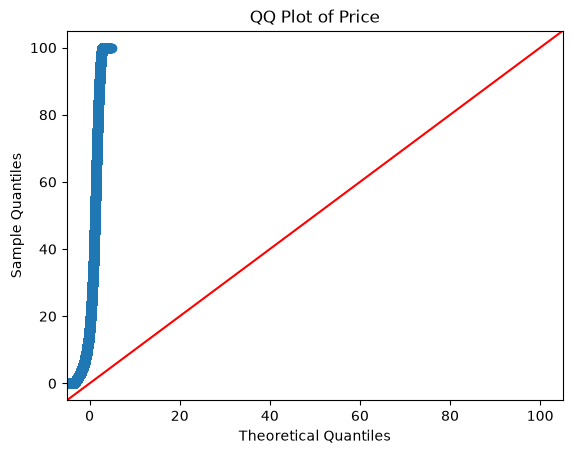

In [18]:
import statsmodels.api as sm

fig = sm.qqplot(df_no_outliers['price'], line='45')
plt.title('QQ Plot of Price')
plt.show()

No, clearly not. The QQ plot shows sample quantiles rising steeply and then flattening near 100, bowing sharply away from the red 45° reference line rather than tracking it. This is the visual signature of a distribution that's strongly right-skewed and bounded (price can't go below 0, and you've capped outliers via IQR removal, producing that plateau near the upper bound) — the opposite shape of what a normal distribution's QQ plot would show. This confirms, visually, what the mean/median/mode gap and skewness already told you back in the univariate lab: price is not close to normally distributed, even after outlier removal.